![title](imagens/cabec_08g.jpg)

# <font color='green'>Projeto 6 - Marketing para Instituições Financeiras - Parte 05</font>
## <font color='green'>Tratamento de Valores Ausentes - C</font>

## Carregando os Pacotes e o DataSet

In [1]:
# Importação dos Pacotes necessários para este projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Carrega o dataset
df = pd.read_csv("dados/bank-full_parte4.csv") 

In [3]:
# Shape
df.shape

(45211, 19)

In [4]:
# Amostra
df.head()

,Unnamed: 0,age,job,salary,balance,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target,marital,education
0,0,58,management,100000.0,2143,no,yes,no,unknown,5,may,261,1,-1,0,unknown,no,married,tertiary
1,1,44,technician,60000.0,29,no,yes,no,unknown,5,may,151,1,-1,0,unknown,no,single,secondary
2,2,33,entrepreneur,120000.0,2,no,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,married,secondary
3,3,47,blue-collar,20000.0,1506,no,yes,no,unknown,5,may,92,1,-1,0,unknown,no,married,unknown
4,4,33,unknown,0.0,1,no,no,no,unknown,5,may,198,1,-1,0,unknown,no,single,unknown


In [5]:
# Como removemos o id, ao sarvar o arquivo, o pandas cria uma nova coluna de identificação e ele chama de Unnamed:0 
# Vamos removê-la.
df.drop(["Unnamed: 0"], axis = 1, inplace = True)

In [6]:
# Amostra
df.head()

,age,job,salary,balance,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target,marital,education
0,58,management,100000.0,2143,no,yes,no,unknown,5,may,261,1,-1,0,unknown,no,married,tertiary
1,44,technician,60000.0,29,no,yes,no,unknown,5,may,151,1,-1,0,unknown,no,single,secondary
2,33,entrepreneur,120000.0,2,no,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,married,secondary
3,47,blue-collar,20000.0,1506,no,yes,no,unknown,5,may,92,1,-1,0,unknown,no,married,unknown
4,33,unknown,0.0,1,no,no,no,unknown,5,may,198,1,-1,0,unknown,no,single,unknown


In [7]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  int64  
 1   job        45211 non-null  object 
 2   salary     45180 non-null  float64
 3   balance    45211 non-null  int64  
 4   default    45211 non-null  object 
 5   housing    45211 non-null  object 
 6   loan       45211 non-null  object 
 7   contact    45211 non-null  object 
 8   day        45211 non-null  int64  
 9   month      45211 non-null  object 
 10  duration   45211 non-null  int64  
 11  campaign   45211 non-null  int64  
 12  pdays      45211 non-null  int64  
 13  previous   45211 non-null  int64  
 14  poutcome   45211 non-null  object 
 15  target     45204 non-null  object 
 16  marital    45211 non-null  object 
 17  education  45211 non-null  object 
dtypes: float64(1), int64(7), object(10)
memory usage: 6.2+ MB


In [8]:
# Temos valores nulos?
df.isna().any()

age          False
job          False
salary        True
balance      False
default      False
housing      False
loan         False
contact      False
day          False
month        False
duration     False
campaign     False
pdays        False
previous     False
poutcome     False
target        True
marital      False
education    False
dtype: bool

In [9]:
# Temos valores nulos?
df.isna().sum()

age           0
job           0
salary       31
balance       0
default       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
target        7
marital       0
education     0
dtype: int64

## Tratamento de Valores Ausentes

A próxima coluna com valores ausentes que vamos trabalhar é a de salário (salary).

In [10]:
# Valores ausentes na variável
df.salary.isnull().sum()

31

In [11]:
# Calcula o percentual de valores ausentes na variável salary
df.salary.isnull().mean()*100

0.06856738404370617

Como o percentual é baixo (menos de 30%) não podemos eliminar a coluna. 
Assim como nos casos anteriores, aqui também ocorrem as suas possibilidades já informadas: 1) Eliminar os registros com valores ausentes (nesse caso perderíamos 31 linhas no dataset) ou 2) Aplicar imputação nos valores ausentes.

Além disso... você notou que existem valores iguais a zero nessa coluna? Existe salário igual a zero?
Pode até existir!!  Portanto, quando se deparar com uma situação semelhante, você tem que confirmar com a área de negócio.
NÃO PODE EXISTIR ACHISMOS!! NUNCA!!  PARA REALIZARMOS QUALQUER MODIFICAÇÃO NOS DADOS, TEMOS QUE TER CERTEZA!!


In [12]:
df.head()

,age,job,salary,balance,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target,marital,education
0,58,management,100000.0,2143,no,yes,no,unknown,5,may,261,1,-1,0,unknown,no,married,tertiary
1,44,technician,60000.0,29,no,yes,no,unknown,5,may,151,1,-1,0,unknown,no,single,secondary
2,33,entrepreneur,120000.0,2,no,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,married,secondary
3,47,blue-collar,20000.0,1506,no,yes,no,unknown,5,may,92,1,-1,0,unknown,no,married,unknown
4,33,unknown,0.0,1,no,no,no,unknown,5,may,198,1,-1,0,unknown,no,single,unknown


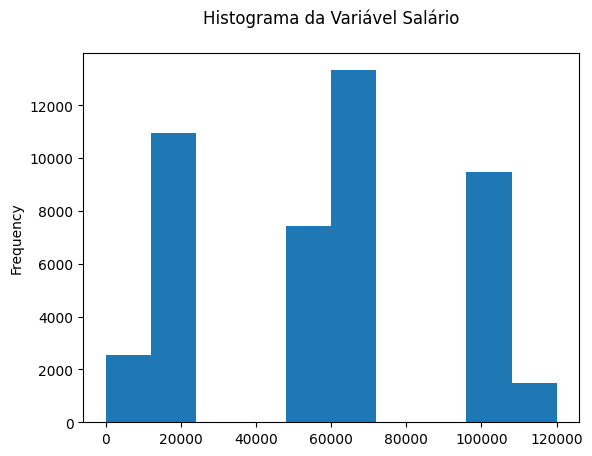

In [13]:
# Histograma
df.salary.plot(kind = "hist")
plt.title("Histograma da Variável Salário\n")
plt.show()

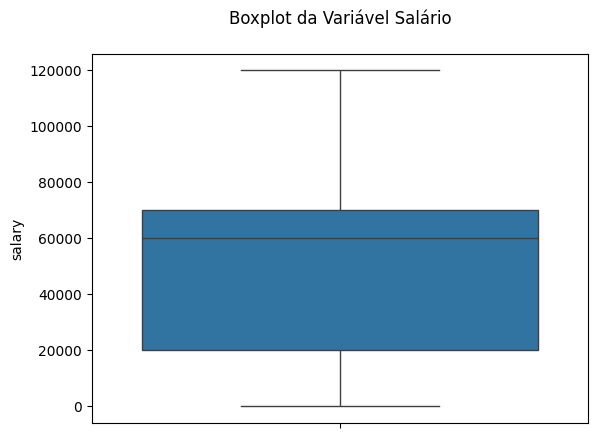

In [14]:
# Boxplot
sns.boxplot(df.salary)
plt.title("Boxplot da Variável Salário\n")
plt.show()

In [15]:
# Vamos verificar qual é a média salarial.
df.salary.mean()

57009.65028773794

In [16]:
# Vamos verificar qual é a mediana.
df.salary.median()

60000.0

In [17]:
# Vamos verificar qual é a moda.
df.salary.mode()

0    20000.0
Name: salary, dtype: float64

Para imputar os valores ausentes da variável salary (salário) com uma medida de tendência central, temos que decidir qual utilizar. 
Também precisamos tratar os valores iguais a zero. 

Ao observarmos os dados, percebemos que os mesmos parecem "assimétricos"
Para dados assimétricos a média não poderia ser utilizada, pois vai mudar o padrão dos dados. A moda também não, pois está muito abaixo da média.

Portanto, a medida mais indicada para este caso é a utilização da mediana.

In [18]:
# Vamos preencher com a mediana os valores ausentes nesta coluna
df.salary.fillna("60000", inplace = True)

In [19]:
df.head()

,age,job,salary,balance,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target,marital,education
0,58,management,100000.0,2143,no,yes,no,unknown,5,may,261,1,-1,0,unknown,no,married,tertiary
1,44,technician,60000.0,29,no,yes,no,unknown,5,may,151,1,-1,0,unknown,no,single,secondary
2,33,entrepreneur,120000.0,2,no,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,married,secondary
3,47,blue-collar,20000.0,1506,no,yes,no,unknown,5,may,92,1,-1,0,unknown,no,married,unknown
4,33,unknown,0.0,1,no,no,no,unknown,5,may,198,1,-1,0,unknown,no,single,unknown


In [21]:
# Histograma (vai gerar erro)
df.salary.plot(kind = "hist")
plt.title("Histograma da Variável Salário\n")
plt.show()

TypeError: no numeric data to plot

In [22]:
# Tipo da variável
df.salary.dtypes

dtype('O')

In [23]:
# Convertemos para o tipo float
df.salary = df.salary.astype("float")

In [24]:
# Tipo da variável
df.salary.dtypes

dtype('float64')

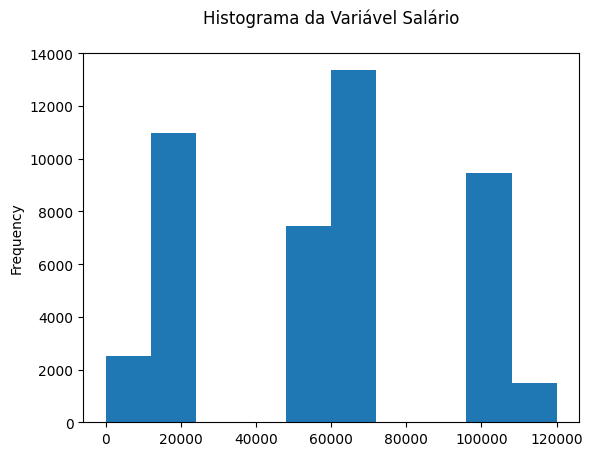

In [25]:
# Histograma
df.salary.plot(kind = "hist")
plt.title("Histograma da Variável Salário\n")
plt.show()

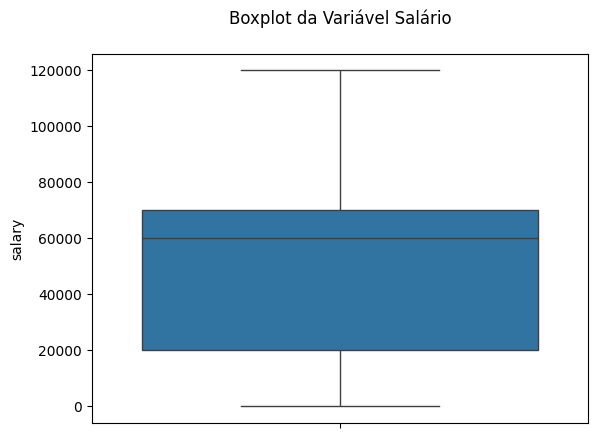

In [26]:
# Boxplot
sns.boxplot(df.salary)
plt.title("Boxplot da Variável Salário\n")
plt.show()

In [27]:
# Registros para cada salário
df.salary.value_counts()

salary
20000.0     9724
100000.0    9454
60000.0     9198
50000.0     5165
70000.0     4153
55000.0     2264
120000.0    1486
8000.0      1303
16000.0     1239
4000.0       937
0.0          288
Name: count, dtype: int64

In [28]:
# Replace do zero pela mediana
df['salary'] = df['salary'].replace(0, df['salary'].median())

In [29]:
# Registros para cada salário
df.salary.value_counts()

salary
20000.0     9724
60000.0     9486
100000.0    9454
50000.0     5165
70000.0     4153
55000.0     2264
120000.0    1486
8000.0      1303
16000.0     1239
4000.0       937
Name: count, dtype: int64

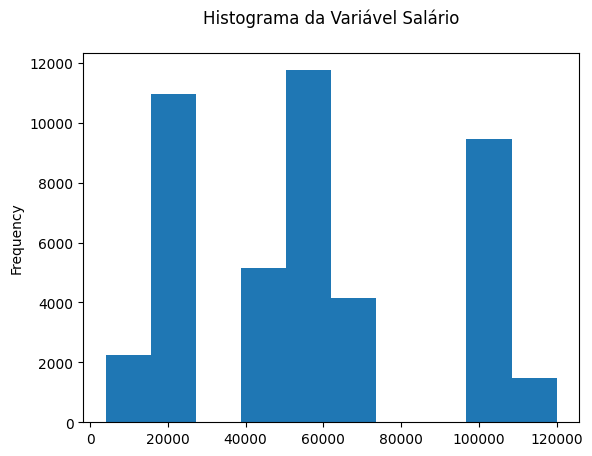

In [30]:
# Histograma
df.salary.plot(kind = "hist")
plt.title("Histograma da Variável Salário\n")
plt.show()

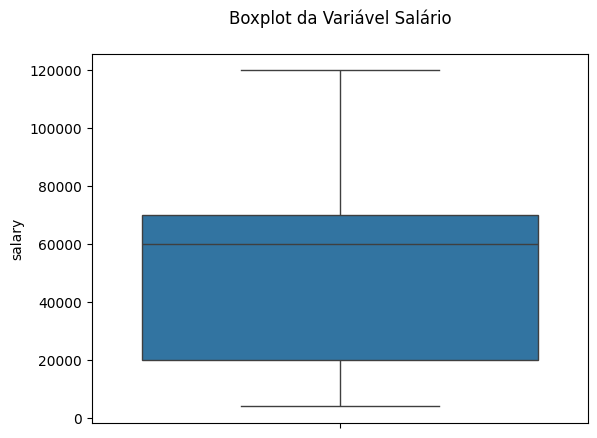

In [31]:
# Boxplot
sns.boxplot(df.salary)
plt.title("Boxplot da Variável Salário\n")
plt.show()

In [32]:
# Calcula o percentual de valores ausentes na variável salary
df.salary.isnull().mean()*100

0.0

In [33]:
df.isna().any()

age          False
job          False
salary       False
balance      False
default      False
housing      False
loan         False
contact      False
day          False
month        False
duration     False
campaign     False
pdays        False
previous     False
poutcome     False
target        True
marital      False
education    False
dtype: bool

## Salvando os Dados desta Etapa 5

In [34]:
# Salvando os dados
df.to_csv('dados/bank-full_parte5.csv')

## Fim da Parte 5